In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

filepath='../data/combined+cycle+power+plant/CCPP/Folds5x2_pp.xlsx'
df_o = pd.read_excel(filepath)

X_col = 'V'
y_col = 'PE'

df = df_o[[X_col, y_col]].dropna()

X = np.asarray(df[[X_col]])
y = np.asarray(df[y_col])

data = {'X': X.reshape(1,-1)[0],'y': y}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

data_train = {'X': X_train.reshape(1,-1)[0],'y': y_train}
data_test = {'X': X_test.reshape(1,-1)[0],'y': y_test}

step = 0.01
X_line = np.arange(X.min(), X.max() + step, step).reshape(-1, 1)

In [36]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(X_train, y_train)
y_line_slr = model.predict(X_line)

In [37]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=8)
model.fit(X_train, y_train)
y_line_knn = model.predict(X_line)

In [38]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics.pairwise import euclidean_distances

class KernelKNNRegressor(BaseEstimator, RegressorMixin):
    """
    KNN Regressor with kernel weighting functions.
    
    Parameters:
    -----------
    k : int, default=8
        Number of neighbors to consider
    kernel : str, default='gaussian'
        Type of kernel: 'cosine', 'epanechnikov', 'exponential', 'gaussian', 'triangular', 'uniform'
    """
    
    def __init__(self, k=8, kernel='gaussian'):
        self.k = k
        self.kernel = kernel
        
    def _kernel_function(self, u):
        """Apply the specified kernel function."""
        if self.kernel == 'cosine':
            return (np.pi/4) * np.cos((np.pi * u) / 2) * (np.abs(u) <= 1)
        elif self.kernel == 'epanechnikov':
            return (3/4) * (1 - u**2) * (np.abs(u) <= 1)
        elif self.kernel == 'exponential':
            return (1/2) * np.exp(-np.abs(u))
        elif self.kernel == 'gaussian':
            return np.exp(-u**2 / 2)
        elif self.kernel == 'triangular':
            return (1 - np.abs(u)) * (np.abs(u) <= 1)
        elif self.kernel == 'uniform':
            return (1/2) * (np.abs(u) <= 1)
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")
    
    def fit(self, X, y):
        """Store training data."""
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self
    
    def predict(self, X):
        """Predict using kernel-weighted KNN."""
        X = np.array(X)
        n_samples = X.shape[0]
        predictions = np.zeros(n_samples)
        
        for i in range(n_samples):
            distances = euclidean_distances(X[i:i+1], self.X_train)[0]
            k_nearest_idx = np.argsort(distances)[:self.k]
            k_distances = distances[k_nearest_idx]
            k_neighbors_y = self.y_train[k_nearest_idx]
            
            max_dist = np.max(k_distances)
            
            if max_dist == 0:
                weights = np.ones_like(k_distances)
            else:
                normalized_distances = k_distances / max_dist
                weights = self._kernel_function(normalized_distances)
                weights = np.maximum(weights, 0)
            
            if np.sum(weights) > 0:
                predictions[i] = np.sum(weights * k_neighbors_y) / np.sum(weights)
            else:
                predictions[i] = np.mean(k_neighbors_y)
                
        return predictions

model = KernelKNNRegressor(k=13, kernel='triangular')
model.fit(X_train, y_train)
y_line_kernel_knn = model.predict(X_line)

In [39]:
class NadarayaWatsonRegressor(BaseEstimator, RegressorMixin):    
    def __init__(self, bandwidth=1.0, kernel='gaussian'):
        self.bandwidth = bandwidth
        self.kernel = kernel
    
    def _kernel_function(self, u):
        if self.kernel == 'cosine':
            return (np.pi/4) * np.cos((np.pi * u) / 2) * (np.abs(u) <= 1)
        elif self.kernel == 'epanechnikov':
            return (3/4) * (1 - u**2) * (np.abs(u) <= 1)
        elif self.kernel == 'exponential':
            return (1/2) * np.exp(-np.abs(u))
        elif self.kernel == 'gaussian':
            return np.exp(-u**2 / 2)
        elif self.kernel == 'triangular':
            return (1 - np.abs(u)) * (np.abs(u) <= 1)
        elif self.kernel == 'uniform':
            return (1/2) * (np.abs(u) <= 1)
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")
    
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self
    
    def predict(self, X):
        X = np.array(X)
        predictions = np.zeros(len(X))
        
        for i, x in enumerate(X):
            # Calculate distances to ALL training points
            distances = euclidean_distances([x], self.X_train)[0]
            
            # Apply kernel with bandwidth
            u = distances / self.bandwidth
            weights = self._kernel_function(u)/self.bandwidth
            
            # Nadaraya-Watson weighted average
            if np.sum(weights) > 0:
                predictions[i] = np.sum(weights * self.y_train) / np.sum(weights)
            else:
                predictions[i] = np.mean(self.y_train)
        
        return predictions
        
model = NadarayaWatsonRegressor(bandwidth=1, kernel='triangular')
model.fit(X_train, y_train)
y_line_nw = model.predict(X_line)

In [40]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1)
model.fit(X_train, y_train)
y_line_ridge = model.predict(X_line)

In [41]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics.pairwise import euclidean_distances

class KernelRidgeRegression(BaseEstimator, RegressorMixin):
    """
    Kernel Ridge Regression with different kernel functions.
    
    Parameters:
    -----------
    alpha : float, default=1.0
        Regularization strength (lambda)
    kernel : str, default='gaussian'
        Type of kernel: 'linear', 'polynomial2', 'polynomial3', 'gaussian', 'laplacian', 'sigmoidal'
    c : float, default=1.0
        Constant parameter for polynomial and sigmoidal kernels
    gamma : float, default=1.0
        Gamma parameter for RBF kernels (gaussian, laplacian)
    alpha_sigmoid : float, default=1.0
        Alpha parameter for sigmoidal kernel
    """
    
    def __init__(self, alpha=1.0, kernel='gaussian', c=1.0, gamma=1.0, alpha_sigmoid=1.0):
        self.alpha = alpha  # regularization strength (lambda)
        self.kernel = kernel
        self.c = c
        self.gamma = gamma
        self.alpha_sigmoid = alpha_sigmoid
    
    def _kernel_matrix(self, X, Y=None):
        """Compute kernel matrix K(X, Y)."""
        if Y is None:
            Y = X
        
        if self.kernel == 'linear':
            # K(x, y) = x^T y
            return X @ Y.T
        
        elif self.kernel == 'polynomial2':
            # K(x, y) = (x^T y + c)^2
            return (X @ Y.T + self.c) ** 2
        
        elif self.kernel == 'polynomial3':
            # K(x, y) = (x^T y + c)^3
            return (X @ Y.T + self.c) ** 3
        
        elif self.kernel == 'gaussian':
            # K(x, y) = exp(-γ ||x - y||^2)
            dist_matrix = euclidean_distances(X, Y, squared=True)
            return np.exp(-self.gamma * dist_matrix)
        
        elif self.kernel == 'laplacian':
            # K(x, y) = exp(-γ ||x - y||)
            dist_matrix = euclidean_distances(X, Y)
            return np.exp(-self.gamma * dist_matrix)
        
        elif self.kernel == 'sigmoidal':
            # K(x, y) = tanh(α x^T y + c)
            return np.tanh(self.alpha_sigmoid * (X @ Y.T) + self.c)
        
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")
    
    def fit(self, X, y):
        """
        Fit Kernel Ridge Regression model.
        
        Solves: min_{β} ||y - Kβ||^2 + α β^T K β
        Solution: β = (K + αI)^{-1} y
        """
        X = np.array(X)
        y = np.array(y)
        
        self.X_train = X
        
        # Compute kernel matrix K
        K = self._kernel_matrix(X)
        
        # Add regularization: (K + αI)
        n = K.shape[0]
        K_reg = K + self.alpha * np.eye(n)
        
        # Solve for coefficients β
        self.beta = np.linalg.solve(K_reg, y)
        
        return self
    
    def predict(self, X):
        """Predict using the kernel model."""
        X = np.array(X)
        
        # Compute kernel between test and training points
        K_test = self._kernel_matrix(X, self.X_train)
        
        # Prediction: f(x) = Σ β_i K(x, x_i)
        return K_test @ self.beta

model = KernelRidgeRegression(alpha=0.001, kernel='laplacian', gamma=1)
model.fit(X_train, y_train)
y_line_kernel_ridge = model.predict(X_line)

In [42]:
def plot_predictions(X_line, y_line, X_train, y_train, X_test, y_test, title=None, name=None):
    plt.figure(figsize=(7, 5))

    default_colors = sns.color_palette()
    seaborn_blue = default_colors[0]  # First color in palette
    seaborn_orange = default_colors[1]  # Second color in palette
    
    # Seaborn scatterplots
    sns.scatterplot(x=X_train.flatten(), y=y_train, alpha=0.5, label='Train', color=seaborn_blue)
    sns.scatterplot(x=X_test.flatten(), y=y_test, alpha=0.5, label='Test', color=seaborn_orange)
    
    # Predicted line (matplotlib is fine for lines)
    plt.plot(X_line, y_line, 'r-', linewidth=2, label='Prediction')
    
    plt.xlabel('V', fontsize=12)
    plt.ylabel('PE', fontsize=12)
    plt.legend(fontsize=10)
    if title:
        plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    # plt.savefig(name)
    plt.show()

plot_predictions(X_line, y_line_kernel_ridge, X_train, y_train, X_test, y_test, title=None, name=None)    

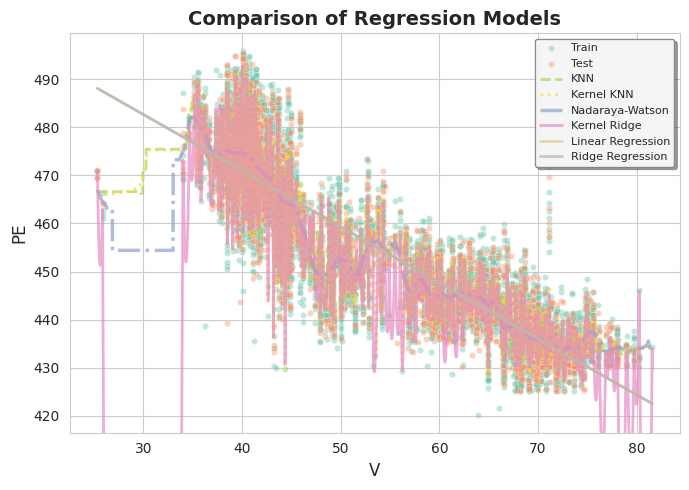

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(7, 5))

# Set a clean seaborn style
sns.set_style("whitegrid")

# Use a qualitative color palette for better distinction
colors = sns.color_palette("Set2", 8)

# Scatterplots for train and test (keep these more visible)
sns.scatterplot(x=X_train.flatten(), y=y_train, alpha=0.4, label='Train', 
                color=colors[0], s=20)
sns.scatterplot(x=X_test.flatten(), y=y_test, alpha=0.4, label='Test', 
                color=colors[1], s=20)

# All predicted lines with lower alpha and better colors
plt.plot(X_line, y_line_knn, color=colors[4], linewidth=2, alpha=0.7, 
         linestyle='--', label='KNN')
plt.plot(X_line, y_line_kernel_knn, color=colors[5], linewidth=2, alpha=0.7, 
         linestyle=':', label='Kernel KNN')
plt.plot(X_line, y_line_nw, color=colors[2], linewidth=2.5, alpha=0.7, 
         linestyle='-.', label='Nadaraya-Watson')
plt.plot(X_line, y_line_kernel_ridge, color=colors[3], linewidth=2, alpha=0.7, 
         linestyle='-', label='Kernel Ridge')
plt.plot(X_line, y_line_slr, color=colors[6], linewidth=2, alpha=0.7, 
         label='Linear Regression')
plt.plot(X_line, y_line_ridge, color=colors[7], linewidth=2, alpha=0.7, 
         label='Ridge Regression')

# Set y-axis limits based ONLY on actual data (train + test)
y_min = min(y_train.min(), y_test.min())
y_max = max(y_train.max(), y_test.max())
y_padding = (y_max - y_min) * 0.05
plt.ylim(y_min - y_padding, y_max + y_padding)

plt.xlabel('V', fontsize=12)
plt.ylabel('PE', fontsize=12)

# Improved legend: one column, better positioning, semi-transparent background
plt.legend(fontsize=8, loc='best', framealpha=0.9, edgecolor='gray', 
           fancybox=True, shadow=True)

plt.title('Comparison of Regression Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

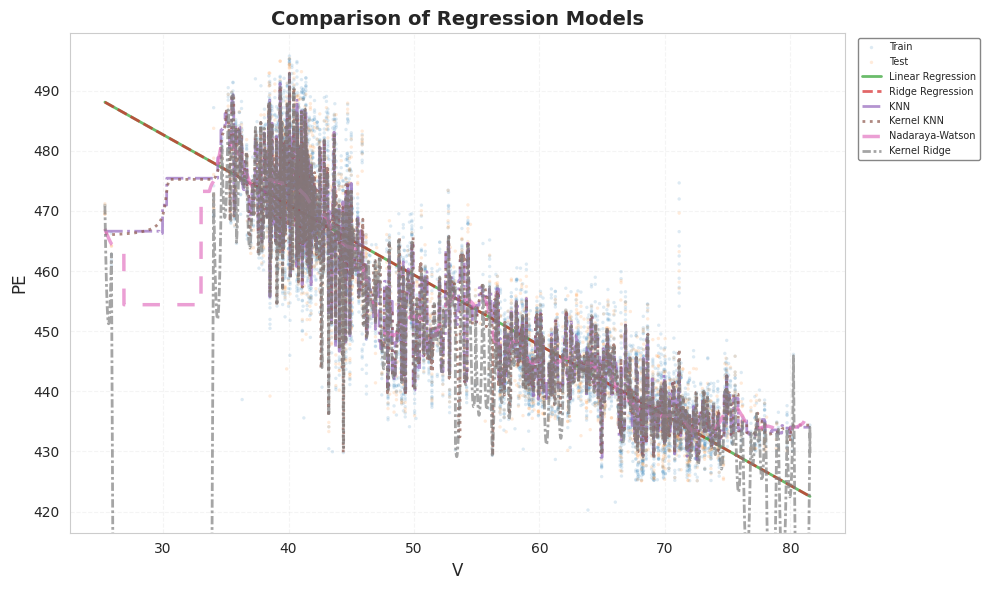

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))

# Use a highly distinct color palette
colors = sns.color_palette("tab10", 8)  # More distinct than Set2

# Make scatter points much smaller and more transparent
sns.scatterplot(x=X_train.flatten(), y=y_train, alpha=0.15, label='Train', 
                color=colors[0], s=6, edgecolor='none')
sns.scatterplot(x=X_test.flatten(), y=y_test, alpha=0.15, label='Test', 
                color=colors[1], s=6, edgecolor='none')

# Define distinct line styles for each model
styles = [
    {'color': colors[2], 'linestyle': '-',  'linewidth': 2, 'alpha': 0.7},  # Linear
    {'color': colors[3], 'linestyle': '--', 'linewidth': 2, 'alpha': 0.7},  # Ridge
    {'color': colors[4], 'linestyle': '-.', 'linewidth': 2, 'alpha': 0.7},  # KNN
    {'color': colors[5], 'linestyle': ':',  'linewidth': 2, 'alpha': 0.7},  # Kernel KNN
    {'color': colors[6], 'linestyle': (0, (5, 5)), 'linewidth': 2.5, 'alpha': 0.7},  # NW (dense dash)
    {'color': colors[7], 'linestyle': (0, (3, 1, 1, 1)), 'linewidth': 2, 'alpha': 0.7}  # Kernel Ridge
]

# Plot all lines
model_names = ['Linear Regression', 'Ridge Regression', 'KNN', 'Kernel KNN', 
               'Nadaraya-Watson', 'Kernel Ridge']
model_lines = [y_line_slr, y_line_ridge, y_line_knn, y_line_kernel_knn, 
               y_line_nw, y_line_kernel_ridge]

for y_line, name, style in zip(model_lines, model_names, styles):
    plt.plot(X_line, y_line, label=name, **style)

# Set y-axis limits based on data
y_min = min(y_train.min(), y_test.min())
y_max = max(y_train.max(), y_test.max())
y_padding = (y_max - y_min) * 0.05
plt.ylim(y_min - y_padding, y_max + y_padding)

plt.xlabel('V', fontsize=12)
plt.ylabel('PE', fontsize=12)

# Legend: 2 columns to save space, placed outside or inside with transparency
plt.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.01, 1), 
           ncol=1, framealpha=0.95, edgecolor='gray')

plt.title('Comparison of Regression Models', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()